<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/thermodynamics/LawsOfThermodynamics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# The laws of thermodynamics with NeqSim

**Audience.** Process-engineering students and practitioners who want to connect the zeroth,
first, second, and third laws to reproducible fluid and process calculations.

**Prerequisites.** Basic algebra, SI units, pressure, temperature, enthalpy, entropy, and a first
course in thermodynamics. Familiarity with Python is helpful but not required.

**Learning objectives.** You will learn to:

1. build and equilibrate a natural-gas fluid with the SRK equation of state;
2. verify the enthalpy definition and path independence of state functions;
3. apply the first law to a rigid vessel and a steady-flow process;
4. quantify entropy generation for heating, compression, and cooling;
5. compare reversible and irreversible compression;
6. calculate physical flow exergy and explore efficiency sensitivities;
7. distinguish model reference states from the third-law definition of absolute entropy.

All quantities use SI or accepted SI-derived units. The synthetic gas contains no proprietary
data, and every numerical conclusion is checked in code.


In [1]:
import importlib.metadata
import subprocess
import sys


try:
    neqsim_version = importlib.metadata.version("neqsim")
except importlib.metadata.PackageNotFoundError:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--quiet",
            "neqsim",
        ]
    )
    neqsim_version = importlib.metadata.version("neqsim")

print(f"NeqSim version: {neqsim_version}")


NeqSim version: 3.16.0


## 1. Imports and calculation conventions

The Python package starts NeqSim's Java thermodynamic engine through JPype. We use supported
Python helpers for fluids and unit operations and the native `ThermodynamicOperations` class for
TP, PS, PH, and VU flashes. Heat entering a system and shaft work entering a compressor are
positive; cooler duty is therefore negative.


In [2]:
import math

import jpype
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from neqsim import jneqsim
from neqsim.process import clearProcess, compressor, cooler, heater, runProcess, stream
from neqsim.thermo import fluid


plt.style.use("seaborn-v0_8-whitegrid")
ThermodynamicOperations = (
    jneqsim.thermodynamicoperations.ThermodynamicOperations
)

print(f"Python version: {sys.version.split()[0]}")
print(f"Java version: {jpype.JClass('java.lang.System').getProperty('java.version')}")


Python version: 3.12.13
Java version: 17.0.19


## 2. Thermodynamic model and synthetic gas

We choose Soave–Redlich–Kwong (SRK) with the classic mixing rule because the hydrocarbon-rich
gas remains single phase throughout the study. Cubic equations of state calculate phase
equilibrium and residual properties from pressure, temperature, composition, and mixing rules.

$$
P = \frac{RT}{v-b} - \frac{a\alpha}{v(v+b)}
$$

Here $P$ is pressure in Pa, $T$ is temperature in K, $v$ is molar volume in m³/mol, and $a$,
$b$, and $\alpha$ are mixture parameters. SRK is not a universal model for associating liquids,
electrolytes, solids, or highly accurate critical-region work.


In [3]:
base_fluid = fluid("srk", temperature=298.15, pressure=50.0)
gas_composition = {
    "methane": 0.900,
    "ethane": 0.060,
    "propane": 0.020,
    "nitrogen": 0.010,
    "CO2": 0.010,
}

for component_name, mole_fraction in gas_composition.items():
    base_fluid.addComponent(component_name, mole_fraction)

base_fluid.setMixingRule("classic")
base_operations = ThermodynamicOperations(base_fluid)
base_operations.TPflash()
base_fluid.initProperties()

assert math.isclose(sum(gas_composition.values()), 1.0, abs_tol=1.0e-12)
assert base_fluid.getNumberOfPhases() == 1
print(f"Base phase: {base_fluid.getPhase(0).getType()}")


Base phase: GAS


## 3. Zeroth law and equilibrium state

The zeroth law makes temperature a meaningful state variable: systems in thermal equilibrium
with the same reference are in equilibrium with each other. A TP flash imposes one temperature
and pressure and solves for the stable phase state. Cloning the fluid and repeating the flash at
the same conditions must reproduce the same intensive properties.


In [4]:
equilibrium_clone = base_fluid.clone()
equilibrium_clone.setTemperature(25.0, "C")
equilibrium_clone.setPressure(50.0, "bara")
clone_operations = ThermodynamicOperations(equilibrium_clone)
clone_operations.TPflash()
equilibrium_clone.initProperties()

zeroth_law_check = pd.Series(
    {
        "Temperature difference [K]": (
            equilibrium_clone.getTemperature("K")
            - base_fluid.getTemperature("K")
        ),
        "Pressure difference [bar]": (
            equilibrium_clone.getPressure("bar")
            - base_fluid.getPressure("bar")
        ),
        "Density difference [kg/m³]": (
            equilibrium_clone.getDensity("kg/m3")
            - base_fluid.getDensity("kg/m3")
        ),
    },
    name="repeated TP flash",
)
zeroth_law_check.to_frame()


,repeated TP flash
Temperature difference [K],0.0
Pressure difference [bar],0.0
Density difference [kg/m³],0.0


## 4. Enthalpy is a defined state function

Enthalpy is defined by internal energy plus flow work:

$$
h = u + Pv
$$

For mass-specific quantities, $h$ and $u$ are in kJ/kg, $P$ is in kPa, and $v=1/\rho$ is in
m³/kg. Since 1 kPa·m³ equals 1 kJ, the units close directly. NeqSim's enthalpy and entropy zero
points are conventional reference states; differences, balances, and derivatives are the
physically relevant quantities here.


In [5]:
specific_enthalpy_kj_kg = base_fluid.getEnthalpy("kJ/kg")
specific_internal_energy_kj_kg = base_fluid.getInternalEnergy("kJ/kg")
pressure_kpa = base_fluid.getPressure("bara") * 100.0
specific_volume_m3_kg = base_fluid.getVolume("m3/kg")
flow_work_kj_kg = pressure_kpa * specific_volume_m3_kg

enthalpy_identity_residual_kj_kg = (
    specific_enthalpy_kj_kg
    - specific_internal_energy_kj_kg
    - flow_work_kj_kg
)

pd.Series(
    {
        "Specific enthalpy [kJ/kg]": specific_enthalpy_kj_kg,
        "Specific internal energy [kJ/kg]": specific_internal_energy_kj_kg,
        "Flow work Pv [kJ/kg]": flow_work_kj_kg,
        "Identity residual [kJ/kg]": enthalpy_identity_residual_kj_kg,
    },
    name="enthalpy identity",
).to_frame()


,enthalpy identity
Specific enthalpy [kJ/kg],-4.620435e+00
Specific internal energy [kJ/kg],-1.298109e+02
Flow work Pv [kJ/kg],1.251904e+02
Identity residual [kJ/kg],2.842171e-14


## 5. State functions are path independent

Temperature and pressure can be changed directly or in separate steps. Enthalpy depends only on
the initial and final equilibrium states, so the sum of stepwise enthalpy changes must equal the
direct change. Heat and work would depend on the chosen path, but $\Delta h$ does not.


In [6]:
def flashed_state(source_fluid, temperature_c, pressure_bara):
    state = source_fluid.clone()
    state.setTemperature(float(temperature_c), "C")
    state.setPressure(float(pressure_bara), "bara")
    operations = ThermodynamicOperations(state)
    operations.TPflash()
    state.initProperties()
    return state


initial_state = flashed_state(base_fluid, 25.0, 50.0)
intermediate_state = flashed_state(base_fluid, 80.0, 50.0)
final_state = flashed_state(base_fluid, 80.0, 100.0)

direct_enthalpy_change_kj_kg = (
    final_state.getEnthalpy("kJ/kg")
    - initial_state.getEnthalpy("kJ/kg")
)
stepwise_enthalpy_change_kj_kg = (
    intermediate_state.getEnthalpy("kJ/kg")
    - initial_state.getEnthalpy("kJ/kg")
    + final_state.getEnthalpy("kJ/kg")
    - intermediate_state.getEnthalpy("kJ/kg")
)
path_residual_kj_kg = (
    stepwise_enthalpy_change_kj_kg
    - direct_enthalpy_change_kj_kg
)

print(f"Direct Δh: {direct_enthalpy_change_kj_kg:.9f} kJ/kg")
print(f"Stepwise Δh: {stepwise_enthalpy_change_kj_kg:.9f} kJ/kg")
print(f"Path residual: {path_residual_kj_kg:.3e} kJ/kg")


Direct Δh: 99.734084659 kJ/kg
Stepwise Δh: 99.734084659 kJ/kg
Path residual: 0.000e+00 kJ/kg


## 6. First law for a closed rigid vessel

For a closed system with negligible kinetic and potential energy changes,

$$
\Delta U = Q - W
$$

In a rigid vessel, boundary work is zero, so added heat equals the internal-energy increase. A
VU flash solves temperature and pressure from specified total volume and internal energy. The
raw NeqSim volume and energy are used consistently because VU flash accepts the same native
units returned by the system.


In [7]:
rigid_initial = base_fluid.clone()
rigid_initial_operations = ThermodynamicOperations(rigid_initial)
rigid_initial_operations.TPflash()
rigid_initial.initProperties()

initial_volume_native = rigid_initial.getVolume()
initial_internal_energy_j = rigid_initial.getInternalEnergy()
added_heat_j = 500.0

rigid_final = rigid_initial.clone()
rigid_final_operations = ThermodynamicOperations(rigid_final)
rigid_final_operations.VUflash(
    initial_volume_native,
    initial_internal_energy_j + added_heat_j,
)
rigid_final.initProperties()

rigid_energy_residual_j = (
    rigid_final.getInternalEnergy()
    - initial_internal_energy_j
    - added_heat_j
)
rigid_volume_residual_relative = (
    rigid_final.getVolume() - initial_volume_native
) / initial_volume_native

print(f"Final vessel temperature: {rigid_final.getTemperature('C'):.4f} °C")
print(f"Final vessel pressure: {rigid_final.getPressure('bara'):.4f} bara")
print(f"Energy residual: {rigid_energy_residual_j:.6f} J")


Final vessel temperature: 41.4130 °C
Final vessel pressure: 53.6502 bara
Energy residual: -0.004209 J


## 7. First law for a steady-flow process

For one inlet and one outlet, with negligible kinetic and potential terms,

$$
\dot m(h_{out}-h_{in}) = \dot Q + \dot W_{in}
$$

The example heats 10,000 kg/h of gas, compresses it from 50 to 100 bara, and cools it to 35 °C.
Each NeqSim unit operation consumes the upstream stream and exposes a downstream stream, duty,
or shaft-power result.


In [8]:
clearProcess()

feed_stream = stream("thermodynamic-law feed", base_fluid.clone())
feed_stream.setFlowRate(10_000.0, "kg/hr")
feed_stream.setTemperature(25.0, "C")
feed_stream.setPressure(50.0, "bara")

process_heater = heater("feed heater", feed_stream)
process_heater.setOutTemperature(40.0, "C")

process_compressor = compressor(
    "export compressor",
    process_heater.getOutletStream(),
    100.0,
)
process_compressor.setIsentropicEfficiency(0.78)

process_cooler = cooler(
    "aftercooler",
    process_compressor.getOutletStream(),
)
process_cooler.setOutTemperature(35.0, "C")
runProcess()

process_states = [
    feed_stream,
    process_heater.getOutletStream(),
    process_compressor.getOutletStream(),
    process_cooler.getOutletStream(),
]
process_state_names = ["feed", "heated", "compressed", "cooled"]


## 8. Steady-flow energy closure

The heater duty, compressor input power, and cooler duty should sum to the total enthalpy-flow
change from feed to final product. This overall balance is stronger than checking each unit in
isolation because it also verifies stream connectivity and sign conventions.


In [9]:
mass_flow_kg_s = feed_stream.getFlowRate("kg/sec")
heater_duty_kw = process_heater.getDuty("kW")
compressor_power_kw = process_compressor.getPower("kW")
cooler_duty_kw = process_cooler.getDuty("kW")

feed_enthalpy_kj_kg = feed_stream.getFluid().getEnthalpy("kJ/kg")
product_enthalpy_kj_kg = (
    process_cooler.getOutletStream().getFluid().getEnthalpy("kJ/kg")
)
enthalpy_flow_change_kw = mass_flow_kg_s * (
    product_enthalpy_kj_kg - feed_enthalpy_kj_kg
)
net_energy_input_kw = (
    heater_duty_kw + compressor_power_kw + cooler_duty_kw
)
overall_energy_residual_kw = (
    net_energy_input_kw - enthalpy_flow_change_kw
)

energy_table = pd.Series(
    {
        "Heater duty [kW]": heater_duty_kw,
        "Compressor power [kW]": compressor_power_kw,
        "Cooler duty [kW]": cooler_duty_kw,
        "Net input [kW]": net_energy_input_kw,
        "Enthalpy-flow change [kW]": enthalpy_flow_change_kw,
        "Balance residual [kW]": overall_energy_residual_kw,
    },
    name="steady-flow balance",
)
energy_table.to_frame()


,steady-flow balance
Heater duty [kW],1.037470e+02
Compressor power [kW],3.631671e+02
Cooler duty [kW],-5.420146e+02
Net input [kW],-7.510041e+01
Enthalpy-flow change [kW],-7.510041e+01
Balance residual [kW],-2.842171e-14


## 9. Second law and entropy generation

For a steady unit with heat entering at boundary temperature $T_b$,

$$
\dot S_{gen} = \dot m(s_{out}-s_{in}) - \frac{\dot Q}{T_b}
$$

$\dot S_{gen}$ is in kW/K and cannot be negative for a physically consistent unit. The
compressor is treated as adiabatic. We use 350 K for the heater reservoir and 298.15 K for the
cooling environment; these are explicit engineering assumptions, not NeqSim predictions.


In [10]:
def stream_entropy_kj_kg_k(process_stream):
    return process_stream.getFluid().getEntropy("kJ/kgK")


heater_boundary_temperature_k = 350.0
environment_temperature_k = 298.15

feed_entropy = stream_entropy_kj_kg_k(feed_stream)
heated_entropy = stream_entropy_kj_kg_k(process_heater.getOutletStream())
compressed_entropy = stream_entropy_kj_kg_k(
    process_compressor.getOutletStream()
)
cooled_entropy = stream_entropy_kj_kg_k(process_cooler.getOutletStream())

heater_entropy_generation_kw_k = (
    mass_flow_kg_s * (heated_entropy - feed_entropy)
    - heater_duty_kw / heater_boundary_temperature_k
)
compressor_entropy_generation_kw_k = mass_flow_kg_s * (
    compressed_entropy - heated_entropy
)
cooler_entropy_generation_kw_k = (
    mass_flow_kg_s * (cooled_entropy - compressed_entropy)
    - cooler_duty_kw / environment_temperature_k
)

entropy_generation = pd.Series(
    {
        "Heater [kW/K]": heater_entropy_generation_kw_k,
        "Compressor [kW/K]": compressor_entropy_generation_kw_k,
        "Cooler [kW/K]": cooler_entropy_generation_kw_k,
    },
    name="entropy generation",
)
entropy_generation.to_frame()


,entropy generation
Heater [kW/K],0.043090
Compressor [kW/K],0.214296
Cooler [kW/K],0.230984


## 10. Reversible compression benchmark

An internally reversible adiabatic compressor is isentropic. A PS flash at the discharge
pressure gives the ideal outlet state. Isentropic efficiency for a compressor is

$$
\eta_s = \frac{h_{2s}-h_1}{h_2-h_1}
$$

where state $2s$ is the isentropic outlet and state 2 is the actual outlet. Both enthalpy rises
are positive. The actual discharge should be hotter and require more power.


In [11]:
compressor_inlet_fluid = process_heater.getOutletStream().getFluid()
isentropic_outlet = compressor_inlet_fluid.clone()
inlet_entropy_native = compressor_inlet_fluid.getEntropy()
isentropic_outlet.setPressure(100.0, "bara")
isentropic_operations = ThermodynamicOperations(isentropic_outlet)
isentropic_operations.PSflash(inlet_entropy_native)
isentropic_outlet.initProperties()

inlet_h_kj_kg = compressor_inlet_fluid.getEnthalpy("kJ/kg")
isentropic_h_kj_kg = isentropic_outlet.getEnthalpy("kJ/kg")
actual_h_kj_kg = (
    process_compressor.getOutletStream().getFluid().getEnthalpy("kJ/kg")
)
calculated_isentropic_efficiency = (
    (isentropic_h_kj_kg - inlet_h_kj_kg)
    / (actual_h_kj_kg - inlet_h_kj_kg)
)
isentropic_entropy_residual = (
    isentropic_outlet.getEntropy() - inlet_entropy_native
)

pd.Series(
    {
        "Isentropic outlet [°C]": isentropic_outlet.getTemperature("C"),
        "Actual outlet [°C]": process_compressor.getOutletStream().getTemperature("C"),
        "Calculated efficiency [-]": calculated_isentropic_efficiency,
        "Isentropic entropy residual [J/K]": isentropic_entropy_residual,
    },
    name="compression benchmark",
).to_frame()


,compression benchmark
Isentropic outlet [°C],9.444743e+01
Actual outlet [°C],1.049695e+02
Calculated efficiency [-],7.800000e-01
Isentropic entropy residual [J/K],-6.821210e-12


## 11. Exergy and the lost-work interpretation

Physical flow exergy relative to an environment state is

$$
b = (h-h_0)-T_0(s-s_0)
$$

where $b$ is in kJ/kg and $T_0$ is in K. Chemical exergy is excluded. The Gouy–Stodola theorem
relates exergy destruction to entropy generation: $\dot E_D=T_0\dot S_{gen}$. Exergy depends on
the explicitly chosen environment and is not an intrinsic equipment property.


In [12]:
environment_state = flashed_state(
    base_fluid,
    temperature_c=25.0,
    pressure_bara=1.01325,
)
environment_h_kj_kg = environment_state.getEnthalpy("kJ/kg")
environment_s_kj_kg_k = environment_state.getEntropy("kJ/kgK")


def physical_exergy_kj_kg(process_stream):
    stream_fluid = process_stream.getFluid()
    enthalpy_difference = (
        stream_fluid.getEnthalpy("kJ/kg") - environment_h_kj_kg
    )
    entropy_difference = (
        stream_fluid.getEntropy("kJ/kgK") - environment_s_kj_kg_k
    )
    return enthalpy_difference - environment_temperature_k * entropy_difference


exergy_records = []
for state_name, process_state in zip(process_state_names, process_states):
    exergy_records.append(
        {
            "state": state_name,
            "temperature_C": process_state.getTemperature("C"),
            "pressure_bara": process_state.getPressure("bara"),
            "physical_exergy_kJ_kg": physical_exergy_kj_kg(process_state),
        }
    )

exergy_table = pd.DataFrame(exergy_records)
exergy_table


,state,temperature_C,pressure_bara,physical_exergy_kJ_kg
0,feed,25.000000,50.0,527.698952
1,heated,40.000000,50.0,528.606912
2,compressed,104.969543,100.0,636.345806
3,cooled,35.000000,100.0,611.553391


## 12. Compressor-efficiency sensitivity

The reversible enthalpy rise is fixed by inlet state and discharge pressure. For an assumed
efficiency, the actual rise is $\Delta h=\Delta h_s/\eta_s$. A PH flash then converts the target
enthalpy and pressure into discharge temperature. The study shows why efficiency affects both
power demand and aftercooler duty.


In [13]:
efficiency_values = np.array([0.65, 0.70, 0.75, 0.80, 0.85])
isentropic_enthalpy_rise_kj_kg = (
    isentropic_h_kj_kg - inlet_h_kj_kg
)
efficiency_records = []

for efficiency in efficiency_values:
    target_enthalpy_kj_kg = (
        inlet_h_kj_kg + isentropic_enthalpy_rise_kj_kg / efficiency
    )
    sensitivity_state = compressor_inlet_fluid.clone()
    sensitivity_state.setPressure(100.0, "bara")
    sensitivity_operations = ThermodynamicOperations(sensitivity_state)
    sensitivity_operations.PHflash(
        target_enthalpy_kj_kg,
        "kJ/kg",
    )
    sensitivity_state.initProperties()
    efficiency_records.append(
        {
            "isentropic_efficiency": efficiency,
            "power_kW": (
                mass_flow_kg_s
                * (target_enthalpy_kj_kg - inlet_h_kj_kg)
            ),
            "discharge_temperature_C": sensitivity_state.getTemperature("C"),
        }
    )

efficiency_results = pd.DataFrame(efficiency_records)
efficiency_results


,isentropic_efficiency,power_kW,discharge_temperature_C
0,0.65,435.800576,114.532044
1,0.70,404.671964,110.435227
2,0.75,377.693833,106.882814
3,0.80,354.087968,103.773665
4,0.85,333.259264,101.030133


## 13. Heat-transfer boundary sensitivity

Entropy generation for a given process duty depends on the reservoir temperature. Heat supplied
from a reservoir only slightly hotter than the process is less irreversible than heat supplied
from a very hot reservoir, provided the assumed direction remains physically possible. The
calculation screens thermodynamic consistency; it does not size a heat exchanger.


In [14]:
heater_boundary_temperatures_k = np.array([330.0, 350.0, 400.0, 500.0])
heater_entropy_sensitivity = mass_flow_kg_s * (
    heated_entropy - feed_entropy
) - heater_duty_kw / heater_boundary_temperatures_k

boundary_results = pd.DataFrame(
    {
        "boundary_temperature_K": heater_boundary_temperatures_k,
        "entropy_generation_kW_K": heater_entropy_sensitivity,
        "exergy_destruction_kW": (
            environment_temperature_k * heater_entropy_sensitivity
        ),
    }
)
boundary_results


,boundary_temperature_K,entropy_generation_kW_K,exergy_destruction_kW
0,330.0,0.025125,7.491051
1,350.0,0.043090,12.847273
2,400.0,0.080142,23.894481
3,500.0,0.132016,39.360572


## 14. Limiting case: no pressure ratio

If discharge pressure equals inlet pressure, the reversible compression work tends to zero. This
limiting case is a useful independent check on signs and state handling. It is not a model of
mechanical losses at zero load.


In [15]:
zero_ratio_state = compressor_inlet_fluid.clone()
zero_ratio_state.setPressure(
    compressor_inlet_fluid.getPressure("bara"),
    "bara",
)
zero_ratio_operations = ThermodynamicOperations(zero_ratio_state)
zero_ratio_operations.PSflash(inlet_entropy_native)
zero_ratio_state.initProperties()

zero_ratio_enthalpy_change_kj_kg = (
    zero_ratio_state.getEnthalpy("kJ/kg") - inlet_h_kj_kg
)
zero_ratio_temperature_change_c = (
    zero_ratio_state.getTemperature("C")
    - compressor_inlet_fluid.getTemperature("C")
)

print(
    "Zero-ratio enthalpy change: "
    f"{zero_ratio_enthalpy_change_kj_kg:.3e} kJ/kg"
)
print(
    "Zero-ratio temperature change: "
    f"{zero_ratio_temperature_change_c:.3e} °C"
)


Zero-ratio enthalpy change: 0.000e+00 kJ/kg
Zero-ratio temperature change: 0.000e+00 °C


## 15. Engineering visualization

The first panel follows temperature and physical exergy through the process. The second figure
shows the compression trade-off: increasing efficiency lowers both shaft power and discharge
temperature. Axes carry explicit SI-derived units so the figures remain interpretable when
copied into teaching notes or an engineering report.


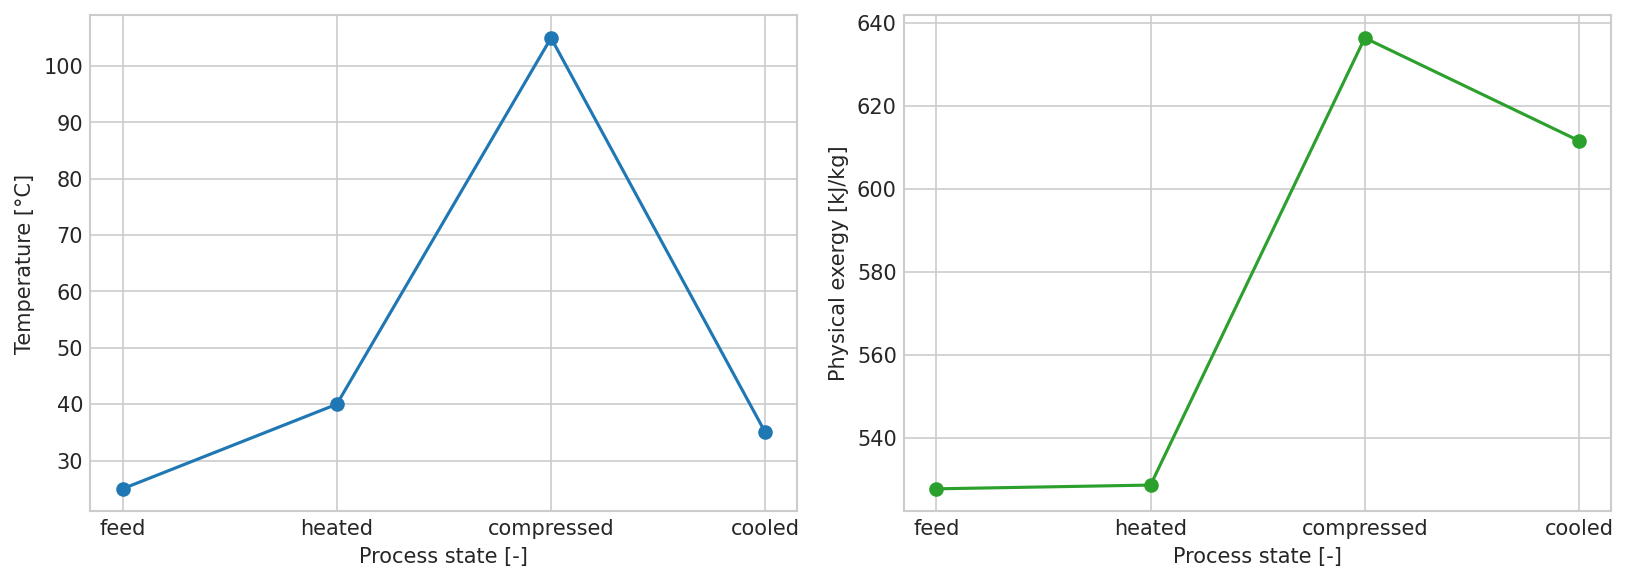

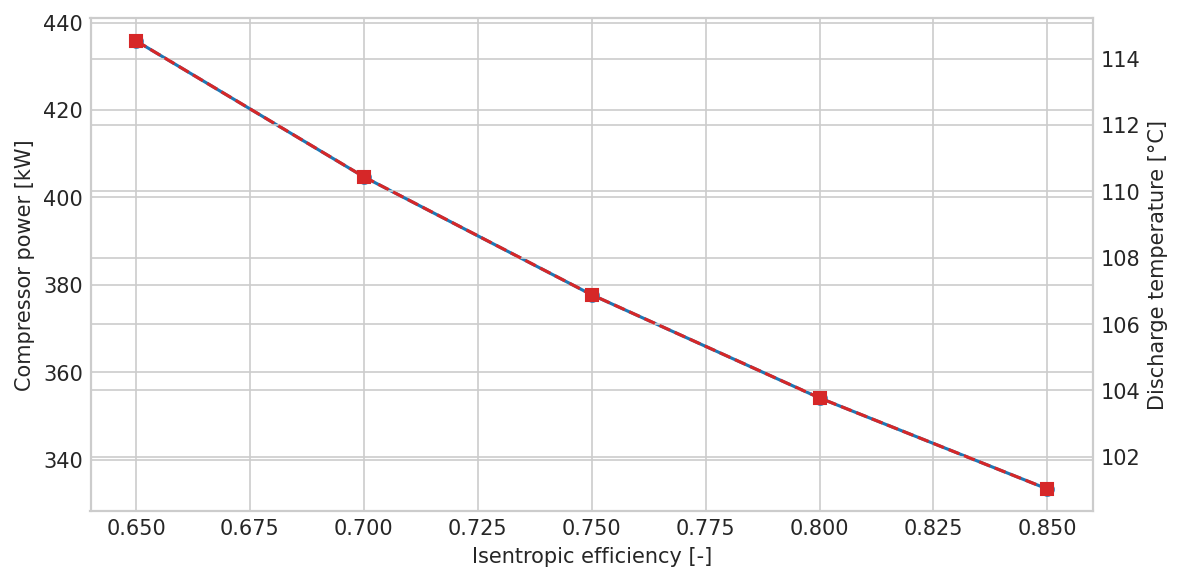

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
state_positions = np.arange(len(exergy_table))
axes[0].plot(
    state_positions,
    exergy_table["temperature_C"],
    "o-",
)
axes[0].set_xticks(state_positions, exergy_table["state"])
axes[0].set_ylabel("Temperature [°C]")
axes[0].set_xlabel("Process state [-]")

axes[1].plot(
    state_positions,
    exergy_table["physical_exergy_kJ_kg"],
    "o-",
    color="tab:green",
)
axes[1].set_xticks(state_positions, exergy_table["state"])
axes[1].set_ylabel("Physical exergy [kJ/kg]")
axes[1].set_xlabel("Process state [-]")
fig.tight_layout()

fig, power_axis = plt.subplots(figsize=(8, 4))
temperature_axis = power_axis.twinx()
power_axis.plot(
    efficiency_results["isentropic_efficiency"],
    efficiency_results["power_kW"],
    "o-",
    label="power",
)
temperature_axis.plot(
    efficiency_results["isentropic_efficiency"],
    efficiency_results["discharge_temperature_C"],
    "s--",
    color="tab:red",
    label="discharge temperature",
)
power_axis.set_xlabel("Isentropic efficiency [-]")
power_axis.set_ylabel("Compressor power [kW]")
temperature_axis.set_ylabel("Discharge temperature [°C]")
fig.tight_layout()


## 16. Third law, reference states, and model scope

The third law assigns zero entropy to a perfect crystal at 0 K and enables absolute entropy
tables. Engineering simulators commonly use internally consistent reference states instead.
Consequently, NeqSim entropy values may be negative relative to their chosen zero without
violating the second law. Entropy differences, derivatives, and closed balances are meaningful;
mixing values from different reference conventions is not.

The present study excludes chemical reaction, chemical exergy, multiphase flow, pressure drop,
equipment heat loss, transient inventory, and kinetic or potential energy. Those terms must be
included when they materially affect the real system.


In [17]:
reference_state_summary = pd.Series(
    {
        "Feed entropy [kJ/(kg K)]": feed_entropy,
        "Product entropy [kJ/(kg K)]": cooled_entropy,
        "Entropy difference [kJ/(kg K)]": (
            cooled_entropy - feed_entropy
        ),
        "Environment temperature [K]": environment_temperature_k,
        "Feed physical exergy [kJ/kg]": (
            exergy_table.loc[
                exergy_table["state"] == "feed",
                "physical_exergy_kJ_kg",
            ].iloc[0]
        ),
    },
    name="reference-state interpretation",
)
reference_state_summary.to_frame()


,reference-state interpretation
Feed entropy [kJ/(kg K)],-1.574550
Product entropy [kJ/(kg K)],-1.946479
Entropy difference [kJ/(kg K)],-0.371929
Environment temperature [K],298.150000
Feed physical exergy [kJ/kg],527.698952


## 17. Verification checks

The checks below cover equilibrium reproducibility, state-function identities, closed- and
open-system first-law balances, nonnegative entropy generation, reversible compression,
efficiency recovery, monotonic sensitivity trends, exergy finiteness, and the zero-pressure-ratio
limit. They are calculation checks, not universal equipment acceptance criteria.


In [18]:
assert zeroth_law_check.abs().max() < 1.0e-10
assert abs(enthalpy_identity_residual_kj_kg) < 1.0e-8
assert abs(path_residual_kj_kg) < 1.0e-10
assert abs(rigid_energy_residual_j) < 0.01
assert abs(rigid_volume_residual_relative) < 1.0e-5
assert rigid_final.getTemperature("K") > rigid_initial.getTemperature("K")
assert rigid_final.getPressure("bara") > rigid_initial.getPressure("bara")
assert abs(overall_energy_residual_kw) < 1.0e-8
assert (entropy_generation > 0.0).all()
assert abs(isentropic_entropy_residual) < 1.0e-8
assert math.isclose(calculated_isentropic_efficiency, 0.78, abs_tol=1.0e-10)
assert (
    process_compressor.getOutletStream().getTemperature("C")
    > isentropic_outlet.getTemperature("C")
)
assert efficiency_results["power_kW"].is_monotonic_decreasing
assert efficiency_results["discharge_temperature_C"].is_monotonic_decreasing
assert np.isfinite(exergy_table["physical_exergy_kJ_kg"]).all()
assert (boundary_results["entropy_generation_kW_K"] > 0.0).all()
assert abs(zero_ratio_enthalpy_change_kj_kg) < 1.0e-8
assert abs(zero_ratio_temperature_change_c) < 1.0e-8

print("All 18 thermodynamic verification checks passed.")


All 18 thermodynamic verification checks passed.


## 18. Troubleshooting

- **Import or Java error:** run the setup cell once in a fresh Colab runtime, then execute cells
  in order. Do not restart the Java VM after importing NeqSim.
- **Two phases appear:** inspect the operating condition and select a model appropriate to the
  fluid; this tutorial assumes a single hydrocarbon gas phase.
- **Negative cooler duty:** this is expected under the stated sign convention because heat leaves
  the process stream.
- **Negative absolute entropy value:** check differences and reference-state consistency rather
  than interpreting the arbitrary simulator zero as third-law entropy.
- **Negative entropy generation:** verify heat direction, boundary temperature, units, and stream
  order before interpreting the equipment model.


In [19]:
validation_summary = pd.DataFrame(
    [
        {
            "law": "zeroth",
            "status": "pass",
            "evidence": "repeated TP state reproduced",
        },
        {
            "law": "first, closed",
            "status": "pass",
            "evidence": f"VU residual {rigid_energy_residual_j:.4g} J",
        },
        {
            "law": "first, open",
            "status": "pass",
            "evidence": f"flowsheet residual {overall_energy_residual_kw:.3e} kW",
        },
        {
            "law": "second",
            "status": "pass",
            "evidence": "all entropy-generation rates positive",
        },
        {
            "law": "third",
            "status": "explained",
            "evidence": "simulator reference entropy distinguished from absolute entropy",
        },
    ]
)
validation_summary


,law,status,evidence
0,zeroth,pass,repeated TP state reproduced
1,"first, closed",pass,VU residual -0.004209 J
2,"first, open",pass,flowsheet residual -2.842e-14 kW
3,second,pass,all entropy-generation rates positive
4,third,explained,simulator reference entropy distinguished from...


## 19. Summary, exercises, and references

NeqSim was used to connect all four thermodynamic laws to an SRK fluid, equilibrium flashes, a
rigid-vessel VU flash, and a heater–compressor–cooler process. State-function identities, energy
closure, entropy generation, reversible compression, exergy, sensitivities, and limiting cases
were verified numerically.

**Further exercises**

1. Repeat the process with PR and compare density, power, and entropy generation.
2. Add pipeline pressure loss and include kinetic-energy changes in the first-law balance.
3. Change the environment state and quantify its effect on physical exergy.
4. Add a heat exchanger with two material streams and verify total entropy generation.
5. Construct a closed Brayton cycle and verify net work and cyclic state closure.

**References**

- NeqSim documentation: [thermodynamic models](https://equinor.github.io/neqsim/thermo/thermodynamic_models.html),
  [thermodynamic operations](https://equinor.github.io/neqsim/thermodynamicoperations/README.html),
  and [process recipes](https://equinor.github.io/neqsim/cookbook/process-recipes.html).
- M. J. Moran, H. N. Shapiro, D. D. Boettner, and M. B. Bailey, *Fundamentals of Engineering
  Thermodynamics*, 9th ed., Wiley, 2018.
- Y. A. Çengel and M. A. Boles, *Thermodynamics: An Engineering Approach*, 9th ed.,
  McGraw-Hill, 2019.
